In [16]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  # optional for interactive plots
import networkx as nx     
# optional for graph-based clustering

#for combining scaling and encode
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder,LabelEncoder,OrdinalEncoder
#feature scaling
from sklearn.preprocessing import StandardScaler,MinMaxScaler
#Feature Selection
# Clustering algorithms
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, MeanShift, Birch
# Dimensionality reduction / manifold learning
from sklearn.decomposition import PCA, KernelPCA, FactorAnalysis, TruncatedSVD, SparsePCA
from sklearn.manifold import TSNE, Isomap, MDS, LocallyLinearEmbedding
# Anomaly / outlier detection
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
# Preprocessing & scaling
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer

# Utilities
import joblib  # saving/loading models

In [2]:
data=pd.read_csv("C:/Users/user/Downloads/SCT_TASK_2_Retail Store Customer Segmentation/Mall_Customers.csv")

In [3]:
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


<Axes: xlabel='Gender', ylabel='Annual Income (k$)'>

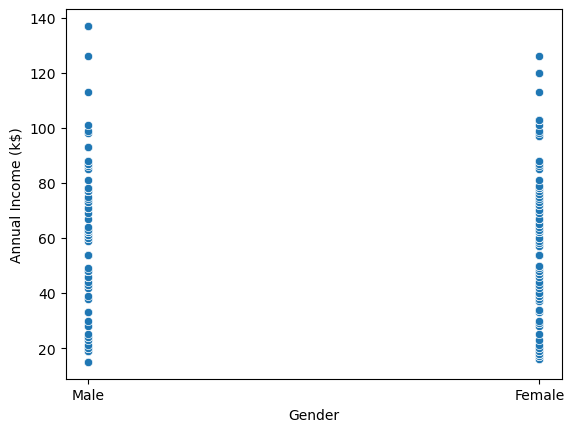

In [4]:
sns.scatterplot(x='Gender',y='Annual Income (k$)',data=data)

<Axes: xlabel='Age', ylabel='Annual Income (k$)'>

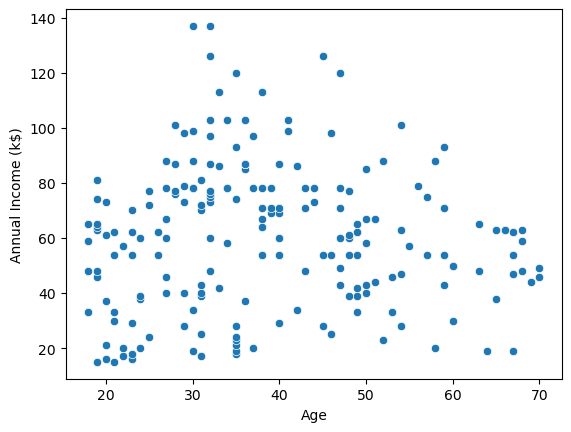

In [5]:
sns.scatterplot(x='Age',y='Annual Income (k$)',data=data)

<Axes: xlabel='Spending Score (1-100)', ylabel='Annual Income (k$)'>

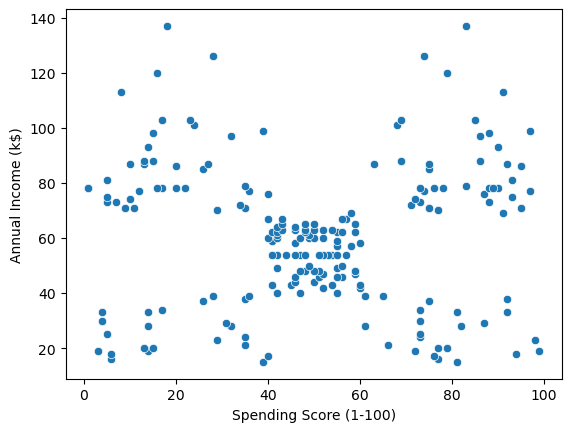

In [6]:
sns.scatterplot(x='Spending Score (1-100)',y='Annual Income (k$)',data=data)

<Axes: xlabel='Spending Score (1-100)', ylabel='Annual Income (k$)'>

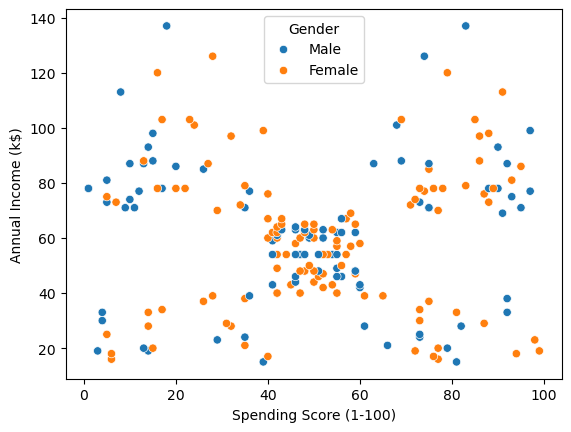

In [7]:
sns.scatterplot(x='Spending Score (1-100)',y='Annual Income (k$)',hue='Gender',data=data)

In [9]:
data = data.drop('CustomerID',axis=1)

In [10]:
data

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']),
        ('cat', OneHotEncoder(drop='first'), ['Gender'])  # Male/Female → 0/1
    ]
)

In [19]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KMeans(n_clusters = 3))
]
)

In [20]:
model.fit_transform(data)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([[2.74204966, 2.31265945, 3.24976771],
       [3.07617675, 1.95210955, 3.91856147],
       [2.93204221, 3.12836983, 3.1342446 ],
       [2.84561285, 1.81867108, 3.75382138],
       [1.94527912, 2.10470692, 2.90771952],
       [2.86473055, 1.79515251, 3.72641623],
       [2.13975788, 3.06402675, 2.7523403 ],
       [3.20785139, 1.95126082, 4.13419644],
       [2.02926819, 4.03713841, 3.23957357],
       [2.3342078 , 1.65363986, 3.4227595 ],
       [1.87060602, 3.92163918, 3.30968042],
       [2.85967109, 2.03533532, 4.09559117],
       [1.49607606, 3.43383295, 2.93759638],
       [2.73306415, 1.66102024, 3.62241121],
       [1.90330945, 2.85448243, 2.62324387],
       [2.91198088, 1.74762805, 3.71330837],
       [1.64147593, 2.15254059, 2.66793306],
       [2.78444412, 1.73853058, 3.44620177],
       [1.13968441, 2.80853141, 2.68194763],
       [2.77565869, 1.89636286, 3.97034614],
       [1.63020734, 2.10694297, 2.55461786],
       [2.57692586, 1.53498164, 3.39218706],
       [1.

In [21]:
clusters = model.named_steps['model'].labels_

In [22]:
data['Cluster'] = clusters
data.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,Male,19,15,39,1
1,Male,21,15,81,1
2,Female,20,16,6,0
3,Female,23,16,77,1
4,Female,31,17,40,0


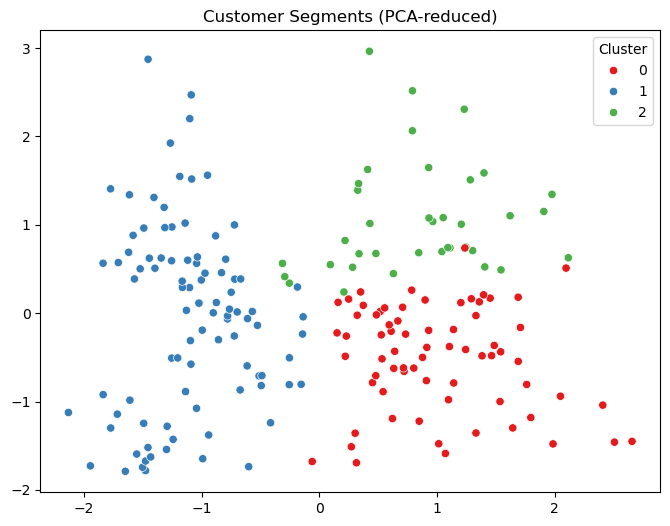

In [25]:
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
X_scaled = model.named_steps['preprocessor'].transform(data.drop('Cluster', axis=1))
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=data['Cluster'], palette='Set1')
plt.title('Customer Segments (PCA-reduced)')
plt.show()

In [28]:
cluster_summary = data.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        52.400000           46.328571               39.371429
1        28.430108           60.709677               70.774194
2        39.405405           87.108108               18.972973
